# 2.6 — Proxy hedging and the hedging pipeline

> *"Amateurs hedge trades. Professionals hedge books."*

## The problem

Module 2 so far has hedged one exposure at a time. A real risk feed looks like this:

| source book | hub | instrument | MWh |
|---|---|---|---|
| MM-Paris | PEG | Dec-26 | +12,400 |
| MM-Paris | PEG | Q1-27 | −9,800 |
| MM-Amsterdam | TTF | Win-26 | +30,000 |
| MM-Amsterdam | TTF | Nov-26 | −22,000 |
| Structured | TTF | Cal-27 | +45,000 |
| ... | | | |

Hedging each line would be wasteful (the Win-26 long and the Nov-26 short partly cancel) and wrong
(Q1-27 must be decomposed by hours). This chapter builds the **pipeline** every hedging engine implements,
end to end, in a few dozen lines on top of `gashedge`:

1. **Decompose** every line into a monthly MWh ladder per hub (Chapter 1.2).
2. **Aggregate** — net across books per (hub, month).
3. **Map** each net cell to a liquid proxy instrument with a hedge ratio (Chapters 1.4, 1.5, 2.3).
4. **Size** in lots (Chapter 1.1) and apply the band (Chapter 2.5).
5. **Report** the residual — what the book still holds after the hedge, in MWh and in risk.

Then we look at what is still missing, which is the agenda of Module 3.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.contracts import *
from gashedge.market_data import simulate_curve_history, simulate_hub_history, month_bucket, liquidity_for
from gashedge.hedging import strip_to_monthly_exposure, min_variance_hedge_ratio, execution_cost
from gashedge.risk import portfolio_variance
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch2.6")
log.info("Environment ready")

2026-09-13 16:47:08.364 | INFO    | ch2.6 | Environment ready


## 1. The risk feed

In [2]:
AS_OF = date(2026, 9, 14)
feed = pd.DataFrame([
    ("MM-Paris",     "PEG", "M",   (2026, 12), None,  +12_400),
    ("MM-Paris",     "PEG", "Q",   (2027, 1),  None,  -9_800),
    ("MM-Paris",     "PEG", "M",   (2026, 11), None,  +6_500),
    ("MM-Amsterdam", "TTF", "WIN", (2026, None), None, +30_000),
    ("MM-Amsterdam", "TTF", "M",   (2026, 11), None,  -22_000),
    ("MM-Amsterdam", "TTF", "M",   (2027, 6),  None,  +8_000),
    ("Structured",   "TTF", "CAL", (2027, None), None, +45_000),
    ("Structured",   "PEG", "SUM", (2027, None), None, -15_000),
], columns=["book", "hub", "kind", "period", "unused", "mwh"]).drop(columns="unused")
feed

,book,hub,kind,period,mwh
0,MM-Paris,PEG,M,"(2026, 12)",12400
1,MM-Paris,PEG,Q,"(2027, 1)",-9800
2,MM-Paris,PEG,M,"(2026, 11)",6500
3,MM-Amsterdam,TTF,WIN,"(2026, None)",30000
4,MM-Amsterdam,TTF,M,"(2026, 11)",-22000
5,MM-Amsterdam,TTF,M,"(2027, 6)",8000
6,Structured,TTF,CAL,"(2027, None)",45000
7,Structured,PEG,SUM,"(2027, None)",-15000


## 2. Step 1 — decompose into a monthly ladder

Strips become months via hours weighting (equation 1.6). Every line ends up as `(hub, year, month, mwh)`.

In [3]:
def months_for(kind, period):
    y, m = period
    if kind == "M":
        return [(y, m)]
    if kind == "Q":
        return quarter_months(y, (m - 1) // 3 + 1)
    if kind in ("SUM", "WIN"):
        return season_months(y, kind)
    return calendar_months(y)

ladder_rows = []
for r in feed.itertuples():
    months = months_for(r.kind, r.period)
    total_h = sum(delivery_hours(y, m) for y, m in months)
    dec = strip_to_monthly_exposure(r.mwh / total_h, months)
    dec["hub"], dec["book"] = r.hub, r.book
    ladder_rows.append(dec)
ladder = pd.concat(ladder_rows, ignore_index=True)
log.info("Decomposed %d feed lines into %d monthly legs", len(feed), len(ladder))
ladder.head(8)

2026-09-13 16:47:08.379 | INFO    | ch2.6 | Decomposed 8 feed lines into 31 monthly legs


,year,month,symbol,hours,mwh,hub,book
0,2026,12,TFMZ26,744,12400.000000,PEG,MM-Paris
1,2027,1,TFMF27,744,-3377.119037,PEG,MM-Paris
2,2027,2,TFMG27,672,-3050.301065,PEG,MM-Paris
3,2027,3,TFMH27,743,-3372.579898,PEG,MM-Paris
4,2026,11,TFMX26,720,6500.000000,PEG,MM-Paris
5,2026,10,TFMV26,745,5116.758242,TTF,MM-Amsterdam
6,2026,11,TFMX26,720,4945.054945,TTF,MM-Amsterdam
7,2026,12,TFMZ26,744,5109.890110,TTF,MM-Amsterdam


## 3. Step 2 — aggregate the net book

Net per (hub, month). Notice the cancellation: the Win-26 long absorbs part of the Nov-26 short, and the two PEG strips overlap.

2026-09-13 16:47:08.387 | INFO    | ch2.6 | Gross exposure 148700 MWh -> net 138810 MWh after aggregation (7% cancels)


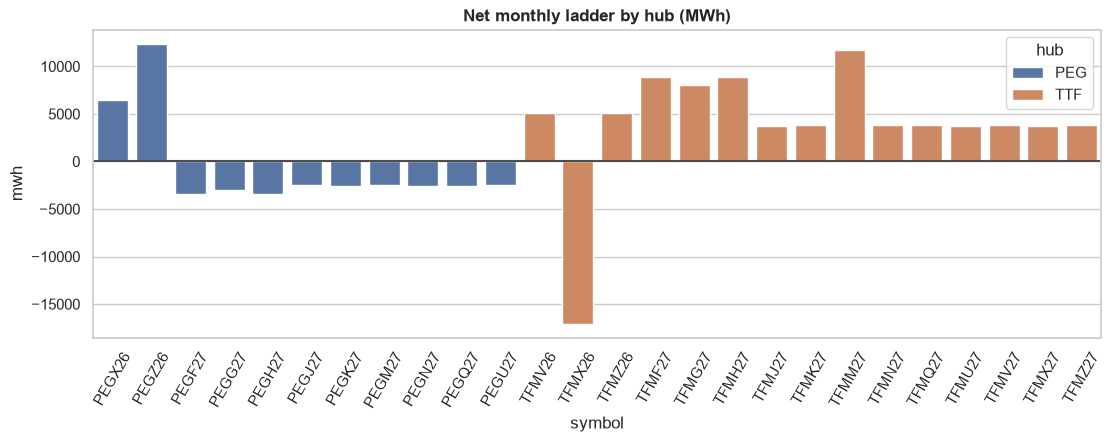

In [4]:
net = ladder.groupby(["hub", "year", "month"], as_index=False)["mwh"].sum()
net = net[net.mwh.abs() > 1e-6].copy()
net["symbol"] = [contract_symbol(y, m, "TFM" if h == "TTF" else "PEG") for h, y, m in zip(net.hub, net.year, net.month)]
net["tenor"] = [(y - AS_OF.year) * 12 + m - AS_OF.month for y, m in zip(net.year, net.month)]
net["hours"] = [delivery_hours(y, m) for y, m in zip(net.year, net.month)]
gross = ladder.mwh.abs().sum()
log.info("Gross exposure %.0f MWh -> net %.0f MWh after aggregation (%.0f%% cancels)", gross, net.mwh.abs().sum(), 100 * (1 - net.mwh.abs().sum() / gross))
fig, ax = plt.subplots(figsize=(13, 4))
sns.barplot(data=net, x="symbol", y="mwh", hue="hub", ax=ax); ax.tick_params(axis="x", rotation=60)
ax.axhline(0, color="0.3"); ax.set_title("Net monthly ladder by hub (MWh)");

## 4. Step 3 — map to liquid proxies with ratios

The mapping policy, in the spirit of Chapter 2.2's "futures for delta, spreads for tenor, basis swaps for
hub":

* **Hub**: all PEG cells are hedged in TTF with the hub ratio $h_{\text{hub}} = \rho\,\sigma_{PEG}/\sigma_{TTF}$
  estimated from history. The PEG–TTF basis is *warehoused* and reported.
* **Tenor**: months 1–3 are hedged in their own contract (liquid). Months 4–12 are *stacked* in M3
  with the tenor ratio from the curve history. Months beyond 12 are stacked in M12. Both stacks are
  flagged for **migration** into the exact strip as liquidity permits.
* **Size**: lots = round(MWh × ratio / hours); the sub-lot remainder is reported.

The ratios come from the simulated histories here; in production they come from Module 3's estimators
with the caveats of Chapter 3.5.

In [5]:
curve_hist = simulate_curve_history(n_days=750, n_tenors=24)
hub_hist = simulate_hub_history(n_days=750)
dC, dH = curve_hist.diff().dropna(), hub_hist.diff().dropna()
h_hub = min_variance_hedge_ratio(dH.PEG, dH.TTF)

def tenor_map(tenor: int) -> tuple[int, float]:
    # returns (hedge tenor, tenor ratio)
    if tenor <= 3:
        return tenor, 1.0
    target = 3 if tenor <= 12 else 12
    return target, min_variance_hedge_ratio(dC[f"M{min(tenor, 24)}"], dC[f"M{target}"])

rows = []
for r in net.itertuples():
    ht, h_tenor = tenor_map(r.tenor)
    hy, hm = add_months(AS_OF.year, AS_OF.month, ht)
    ratio = h_tenor * (h_hub if r.hub == "PEG" else 1.0)
    hedge_mwh = -r.mwh * ratio
    H = delivery_hours(hy, hm)
    lots = round(hedge_mwh / H)
    rows.append({"hub": r.hub, "exposure": r.symbol, "exposure_mwh": r.mwh, "hedge_instrument": contract_symbol(hy, hm),
                 "hedge_tenor": ht, "ratio": ratio, "hedge_mwh": hedge_mwh, "lots": lots,
                 "sub_lot_residual_mwh": hedge_mwh - lots * H, "policy": "direct" if ht == r.tenor else f"stack in M{ht}, migrate"})
plan = pd.DataFrame(rows)
log.info("Hub ratio PEG->TTF = %.3f; %d hedge lines generated", h_hub, len(plan))
plan.round(3)

2026-09-13 16:47:08.555 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:08.560 | INFO    | gashedge.market_data | Simulated 750 days of hub history (crisis=False); TTF range 21.7-59.9


2026-09-13 16:47:08.564 | INFO    | ch2.6 | Hub ratio PEG->TTF = 1.005; 26 hedge lines generated


,hub,exposure,exposure_mwh,hedge_instrument,hedge_tenor,ratio,hedge_mwh,lots,sub_lot_residual_mwh,policy
0,PEG,PEGX26,6500.000,TFMX26,2,1.005,-6535.253,-9,-55.253,direct
1,PEG,PEGZ26,12400.000,TFMZ26,3,1.005,-12467.251,-17,180.749,direct
2,PEG,PEGF27,-3377.119,TFMZ26,3,0.910,3073.363,4,97.363,"stack in M3, migrate"
3,PEG,PEGG27,-3050.301,TFMZ26,3,0.914,2786.989,4,-189.011,"stack in M3, migrate"
4,PEG,PEGH27,-3372.580,TFMZ26,3,0.694,2339.101,3,107.101,"stack in M3, migrate"
5,PEG,PEGJ27,-2459.016,TFMZ26,3,0.750,1843.546,2,355.546,"stack in M3, migrate"
6,PEG,PEGK27,-2540.984,TFMZ26,3,0.771,1960.075,3,-271.925,"stack in M3, migrate"
7,PEG,PEGM27,-2459.016,TFMZ26,3,0.674,1657.235,2,169.235,"stack in M3, migrate"
8,PEG,PEGN27,-2540.984,TFMZ26,3,0.560,1423.745,2,-64.255,"stack in M3, migrate"
9,PEG,PEGQ27,-2540.984,TFMZ26,3,0.571,1451.197,2,-36.803,"stack in M3, migrate"


## 5. Step 4 — net the hedge tickets and apply the band

Several exposures map to the same instrument (everything beyond month 3 lands in M3 or M12). Net the
tickets per instrument, then apply a band from Chapter 2.5: instruments whose net hedge is below the
band are left alone.

In [6]:
BAND_LOTS = 5
tickets = plan.groupby("hedge_instrument", as_index=False).agg(lots=("lots", "sum"), hedge_mwh=("hedge_mwh", "sum"), n_sources=("exposure", "count"))
tickets["hedge_tenor"] = tickets.hedge_instrument.map(plan.drop_duplicates("hedge_instrument").set_index("hedge_instrument").hedge_tenor)
tickets["execute"] = tickets.lots.abs() > BAND_LOTS
tickets["side"] = np.where(tickets.lots > 0, "BUY", "SELL")
liq = [liquidity_for(month_bucket(int(t)), "TTF") for t in tickets.hedge_tenor]
tickets["est_cost_eur"] = [execution_cost(l, q["bid_ask"], 730, q["depth_lots"]) if ex else 0.0 for l, q, ex in zip(tickets.lots, liq, tickets.execute)]
tickets["days_at_10pct_adv"] = [abs(l) / (0.1 * q["est_adv_lots"]) for l, q in zip(tickets.lots, liq)]
log.info("Hedge tickets: %s", tickets[tickets.execute][["side", "hedge_instrument", "lots"]].to_dict("records"))
tickets.round(2)

2026-09-13 16:47:08.575 | INFO    | ch2.6 | Hedge tickets: [{'side': 'SELL', 'hedge_instrument': 'TFMU27', 'lots': -14}, {'side': 'SELL', 'hedge_instrument': 'TFMV26', 'lots': -7}, {'side': 'BUY', 'hedge_instrument': 'TFMX26', 'lots': 15}, {'side': 'SELL', 'hedge_instrument': 'TFMZ26', 'lots': -57}]


,hedge_instrument,lots,hedge_mwh,n_sources,hedge_tenor,execute,side,est_cost_eur,days_at_10pct_adv
0,TFMU27,-14,-10368.29,3,12,True,SELL,819.64,0.14
1,TFMV26,-7,-5116.76,1,1,True,SELL,36.24,0.00
2,TFMX26,15,10519.69,2,2,True,BUY,140.20,0.01
3,TFMZ26,-57,-41110.92,20,3,True,SELL,1118.56,0.07


## 6. Step 5 — the residual report

What is left after the hedge? Three kinds of residual, each with its own owner:

1. **Sub-lot residuals** (quantity) — sum them per month, report, ignore below half a lot.
2. **Tenor residuals** — the stacked months are hedged only up to $\rho^2$ of their variance; the
   remainder is a calendar-spread position awaiting migration.
3. **Hub residual** — the PEG–TTF basis on the entire PEG book.

We can put a single number on the whole thing using the linear model that Chapter 3.1 develops: with
the covariance matrix $\Sigma$ of daily price changes across the instruments and the vector $\Delta$ of
MWh exposures, the daily P&L variance is $\Delta^\top \Sigma \Delta$. Below we assemble $\Delta$ before
and after hedging over the tenor grid (treating PEG cells as TTF cells plus a basis term).

2026-09-13 16:47:08.583 | INFO    | ch2.6 | Hedge reduces daily curve std from 42833 to 9168 EUR; hub basis adds 2319 EUR


daily std before hedge (EUR)                42833.0
daily std after hedge, curve risk (EUR)      9168.0
daily std of warehoused PEG basis (EUR)      2319.0
total after (EUR, assuming independence)     9457.0
dtype: float64

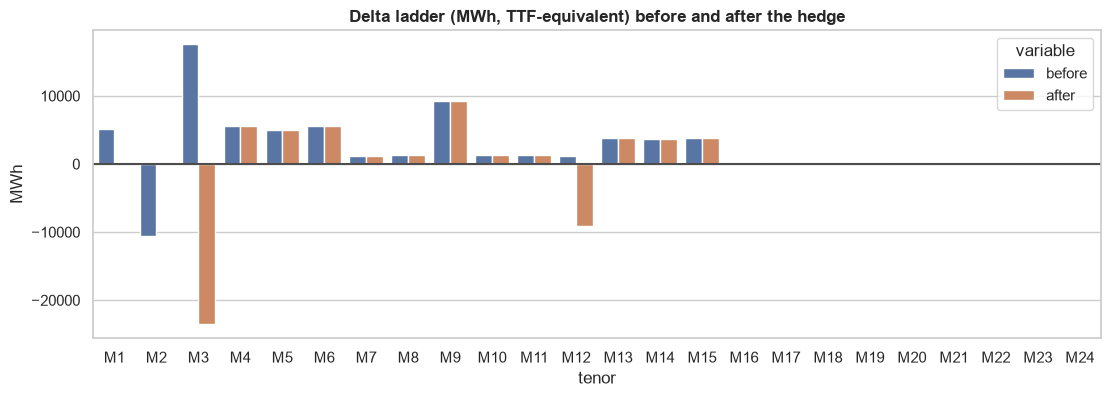

In [7]:
tenors = [f"M{i}" for i in range(1, 25)]
cov = dC[tenors].cov()

def delta_vector(exposures: pd.DataFrame, col: str, tenor_col: str) -> pd.Series:
    v = pd.Series(0.0, index=tenors)
    for r in exposures.itertuples():
        t = int(getattr(r, tenor_col))
        if 1 <= t <= 24:
            v[f"M{t}"] += getattr(r, col)
    return v

delta_before = delta_vector(net.assign(mwh_ttf_equiv=net.mwh * np.where(net.hub == "PEG", h_hub, 1.0)), "mwh_ttf_equiv", "tenor")
delta_hedge = delta_vector(tickets[tickets.execute].assign(t=tickets.hedge_tenor), "hedge_mwh", "t")
delta_after = delta_before + delta_hedge
basis_var = (dH.PEG - h_hub * dH.TTF).var() * (net.loc[net.hub == "PEG", "mwh"].sum()) ** 2
report = pd.Series({
    "daily std before hedge (EUR)": np.sqrt(portfolio_variance(delta_before, cov)),
    "daily std after hedge, curve risk (EUR)": np.sqrt(portfolio_variance(delta_after, cov)),
    "daily std of warehoused PEG basis (EUR)": np.sqrt(basis_var),
    "total after (EUR, assuming independence)": np.sqrt(portfolio_variance(delta_after, cov) + basis_var),
})
log.info("Hedge reduces daily curve std from %.0f to %.0f EUR; hub basis adds %.0f EUR", report.iloc[0], report.iloc[1], report.iloc[2])
fig, ax = plt.subplots(figsize=(13, 4))
long = pd.DataFrame({"before": delta_before, "after": delta_after}).rename_axis("tenor").reset_index().melt(id_vars="tenor")
sns.barplot(data=long, x="tenor", y="value", hue="variable", ax=ax); ax.axhline(0, color="0.3")
ax.set_title("Delta ladder (MWh, TTF-equivalent) before and after the hedge"); ax.set_ylabel("MWh")
report.round(0)

## 7. What the pipeline still cannot tell you

The prototype works, and it is structurally what production systems do. But look at what we *assumed*:

* The **hedge ratios** ($h_{\text{hub}}$, the tenor ratios) were computed by a one-line formula on a
  history we happened to have. How confident are we in them? What is their standard error? Would a
  different window give a different number — and a different P&L?
* The **residual report** used a covariance matrix of 24 tenors estimated from 750 days. Is that even
  well-determined? Should we hedge tenors individually or hedge *factors* (level / slope / curvature)?
* We reported a **standard deviation**. The desk head will ask for a **VaR**, a **stress loss**, and a
  **liquidity horizon**. The regulator will ask whether the VaR was *backtested*.
* The hub ratio (close to 1) came from a *calm* history. Chapter 1.5 showed what a crisis does to it.

Every one of these is a question about **the linear model and its estimation** — the "linear method"
someone mentioned to you. That is Module 3.

## 8. Module 2 in one table

| chapter | decision | rule of thumb |
|---|---|---|
| 2.1 | whether to hedge | minimise variance unless you have edge; costs shrink the hedge toward zero |
| 2.2 | with what | futures for delta, spreads for tenor, cleared basis swaps for hub; watch the cash |
| 2.3 | how much (naïvely) | 1:1 is fine for quantity, tolerable for hub, dangerous for tenor |
| 2.4 | how to maintain | stack by ratio, model the roll, fund the margin — or migrate to strips |
| 2.5 | how often | band ∝ (cost / λ·variance)^{1/3}; hedge realised inventory, not forecasts |
| 2.6 | in what order | decompose → net → map → size → report residual |

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** In the pipeline, a +30,000 MWh Win-26 long and a −22,000 MWh Nov-26 short from the same hub were netted before hedging. What is the net Nov-26 exposure in MWh (Win-26 = Oct-26…Mar-27, hours 745/720/744/744/672/743)? Why would hedging the two lines separately have been strictly worse, not merely more expensive?

<details><summary><i>Answer 1</i></summary>

Win-26 total hours $= 745+720+744+744+672+743 = 4368$; MW $= 30{,}000/4368 = 6.868$ MW; Nov-26 share $= 6.868 \times 720 = \mathbf{4{,}945\ MWh}$ long. Net Nov-26 $= 4{,}945 - 22{,}000 = \mathbf{-17{,}055\ MWh}$. Hedging separately would have bought ~30 lots of Nov (against the strip) and sold ~31 lots of Nov (against the short) — two round-trips of spread and impact for a net trade of ~24 lots, *plus* two sets of rounding residuals with opposite signs that do not cancel exactly. It is worse in cost, in residual, and in information leakage (twice the visible flow).

</details>

**Q2.** The pipeline stacks months 4–12 in M3 rather than in M1. Give two reasons for choosing M3 over M1 as the stacking instrument and one reason a desk might still prefer M1.

<details><summary><i>Answer 2</i></summary>

For M3: (1) **higher correlation and closer volatility** with months 4–12 (Chapter 1.4), so the ratio is nearer 1, the residual variance $(1-\rho^2)$ is smaller, and the hedge is less sensitive to ratio-estimation error; (2) **fewer rolls before migration** — M3 lives three months, M1 expires within weeks, and each roll costs spread and realises the seasonal curve shape (Chapter 2.4). For M1: it is the deepest instrument by an order of magnitude (Chapter 1.3), so for very large or very urgent hedges the execution cost and time saved can outweigh the extra basis — especially if migration to the true strip is planned within days anyway.

</details>

**Q3.** The residual report added the warehoused PEG basis variance to the curve variance 'assuming independence'. Is that assumption conservative or optimistic, and how would you test it with the data in this notebook?

<details><summary><i>Answer 3</i></summary>

It is **neither by construction** — it is exactly right only if $\text{Cov}(\Delta b, \Delta F_i) = 0$ for the residual curve exposures. In practice the basis tends to widen when the front spikes (transport bottlenecks are worth more when gas is expensive — Chapter 1.5), giving positive covariance with front-month risk and making the independence assumption **optimistic** for a book that is net long the front after hedging (and conservative if it is net short). Test: compute the residual daily P&L series from the curve legs ($\Delta_{\text{after}}^\top \Delta P_t$) and the basis P&L series ($Q_{PEG}\,\Delta b_t$) and take their sample covariance / correlation; better, include the basis as an extra 'instrument' in $\Sigma$ and let $\Delta^\top\Sigma\Delta$ do the work (Chapter 3.1).

</details>

**Q4.** A PEG cell of +10,000 MWh in tenor 8 goes through the pipeline. Write down the hedge MWh as a product of ratios, state which two residuals it leaves, and explain what 'migrate' means concretely for this cell.

<details><summary><i>Answer 4</i></summary>

Hedge MWh $= -10{,}000 \times h_{\text{tenor}}(8 \to 3) \times h_{\text{hub}}(PEG \to TTF)$ — e.g. with $h_{\text{tenor}} \approx 0.6$ and $h_{\text{hub}} \approx 0.96$, about $-5{,}800$ MWh of TTF M3 (≈ 8 lots). Residuals: (i) **tenor basis** — the part of month-8 variance uncorrelated with M3, $(1-\rho_{8,3}^2)$, held as a long M8 / short M3 calendar spread; (ii) **hub basis** — the PEG–TTF basis on 10,000 MWh, mean-reverting but regime-sensitive. Migrate: over the following days, sell ~14 lots of the actual TTF month-8 contract (or the quarter containing it) at low participation and simultaneously buy back the ~8 lots of M3, converting the stacked proxy into a direct tenor hedge; optionally, if the PEG book is large, lay off the hub basis in a cleared PEG–TTF basis swap.

</details>


---
◀ [Previous](05_hedge_timing_and_cost.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](../module3_risk_analysis/01_linear_model.ipynb)